In [2]:
# Math & Data manipulation
import copy
import json
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import sympy as sym
import pooch
import os
from pathlib import Path
import gdown

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#import plotnine

# Single-cell analysis
import scanpy as sc
import anndata as ad

# Machine Learning & Deep Learning
#import scvi
#import sklearn
import torch


import scgpt as scg
from scgpt.tasks import GeneEmbedding
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.model import TransformerModel
from scgpt.preprocess import Preprocessor
from scgpt.utils import set_seed



import scib

/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [3]:
"""
Calculate the metrics for integration results
"""
def scib_eval(adata, batch_key, cell_type_key, embed_key):
    results = scib.metrics.metrics(
        adata,
        adata_int=adata,
        batch_key=batch_key,
        label_key=cell_type_key,
        embed=embed_key,
        isolated_labels_asw_=False,
        silhouette_=True,
        hvg_score_=False,
        graph_conn_=True,
        pcr_=True,
        isolated_labels_f1_=False,
        trajectory_=False,
        nmi_=True,  # use the clustering, bias to the best matching
        ari_=True,  # use the clustering, bias to the best matching
        cell_cycle_=False,
        kBET_=False,  # kBET return nan sometimes, need to examine
        ilisi_=False,
        clisi_=False,
    )
    result_dict = results[0].to_dict()
    
    # compute avgBIO metrics
    result_dict["avg_bio"] = np.mean(
        [
            result_dict["NMI_cluster/label"],
            result_dict["ARI_cluster/label"],
            result_dict["ASW_label"],
        ]
    )
    
    # compute avgBATCH metrics
    result_dict["avg_batch"] = np.mean(
        [
            result_dict["graph_conn"],
            result_dict["ASW_label/batch"],
        ]
    )
    
    result_dict = {k: v for k, v in result_dict.items() if not np.isnan(v)}
    
    return result_dict

In [4]:
adata = sc.read_h5ad("data/adata_embedded.h5ad")
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
print(np.isnan(X).sum(), "NaNs across", X.shape)

0 NaNs across (49636, 1926)


In [5]:
# 1. Übersicht - obsm-Einträge werden hier aufgelistet
print(adata)
print('obsm keys:', list(adata.obsm.keys()))



AnnData object with n_obs × n_vars = 49636 × 1926
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', '_scvi_batch', '_scvi_labels'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensembl_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts'

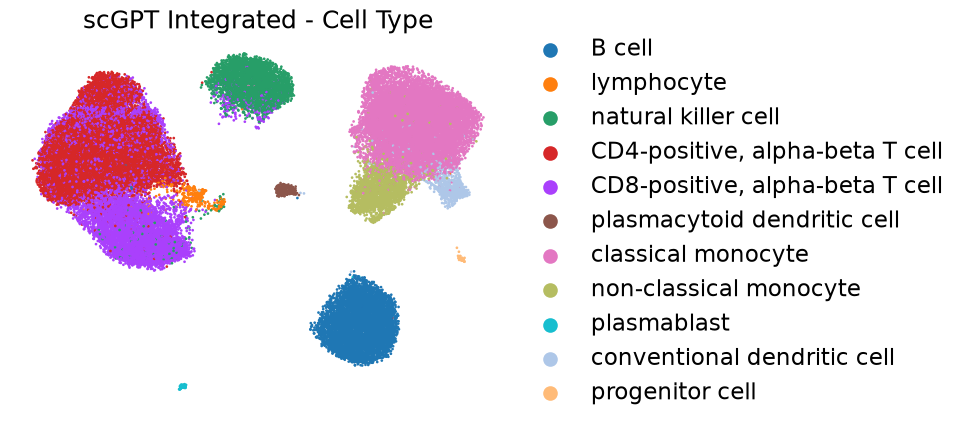

In [6]:
# --- Compute UMAP from scGPT embedding ---
sc.pp.neighbors(adata, use_rep="X_scGPT", key_added="scgpt")
sc.tl.umap(adata, neighbors_key="scgpt")
adata.obsm["X_umap_scgpt"] = adata.obsm.pop("X_umap")  # keep it separate from the other UMAPs

# --- scGPT Integrated ---
sc.pl.embedding(
    adata,
    basis="X_umap_scgpt",
    color=["cell_type"],
    title=["scGPT Integrated - Cell Type"],
    ncols=2,
    size=15,
    frameon=False,
)

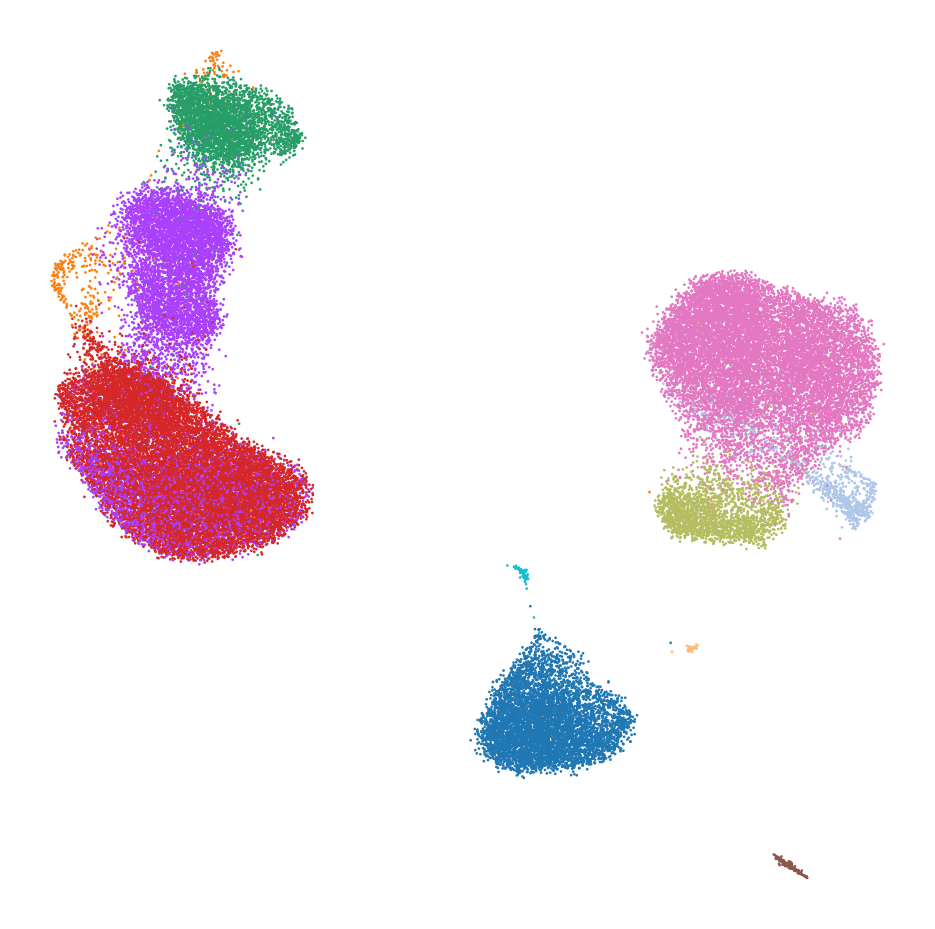

In [27]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_pca",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

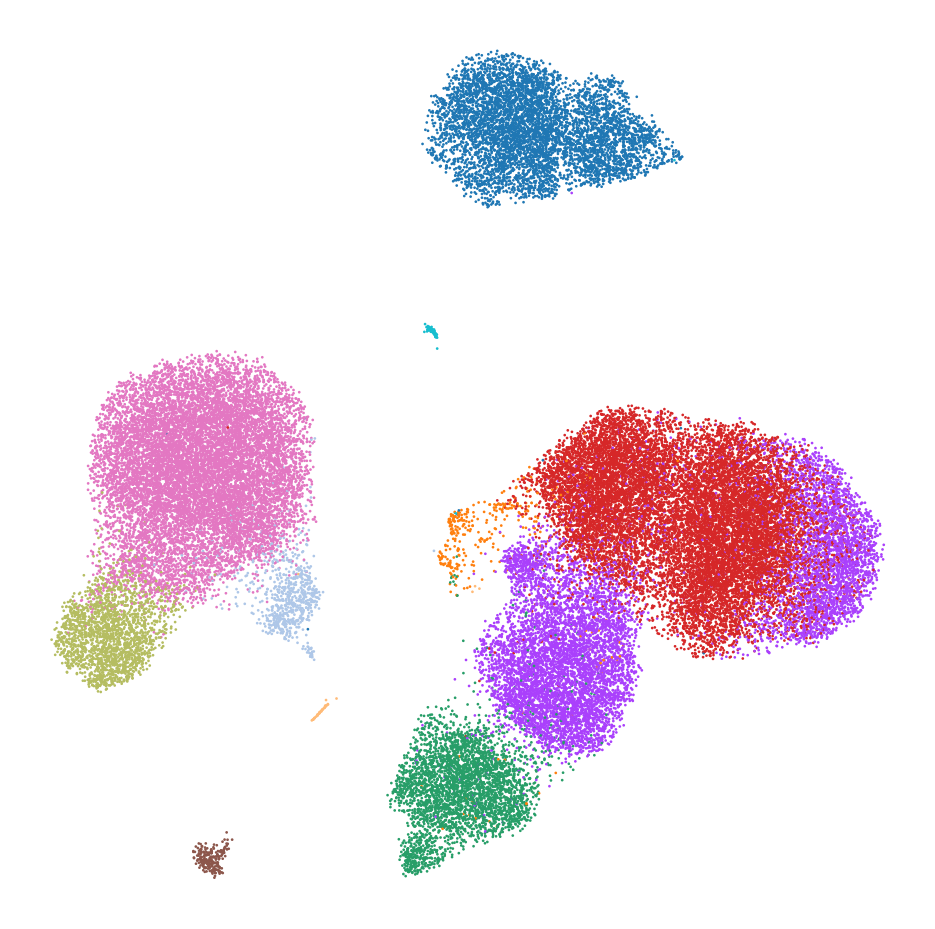

In [28]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_scvi",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

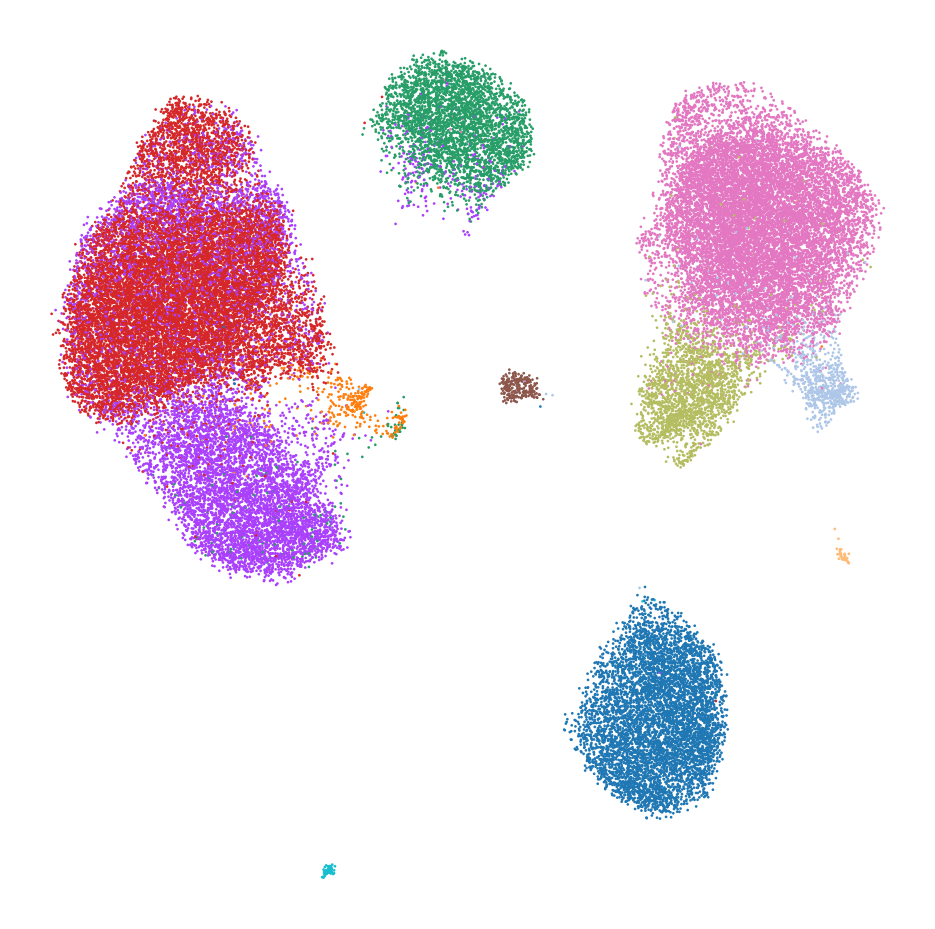

In [25]:
import matplotlib.pyplot as plt
MM = 1 / 25.4

fig, ax = plt.subplots(figsize=(300 * MM, 300 * MM))
sc.pl.embedding(
    adata,
    basis="X_umap_scgpt",
    color="cell_type",
    title="",
    size=15,
    frameon=False,
    legend_loc=None,
    ax=ax,
    show=False,
)
fig.savefig("scgpt_umap.pdf", dpi=300)   # exactly 70×70 mm
plt.show()

In [8]:
adata.uns["pca"].keys()

dict_keys(['connectivities_key', 'distances_key', 'params'])

In [9]:
import numpy as np
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
print(np.isnan(X).sum(), "NaNs across", X.shape)

0 NaNs across (49636, 1926)


In [35]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Representations, per task 3.1:
#   X_pca   -> pre-integration PCA. NOT one of the two graded representations;
#              kept only as an ablation to show integration matters (3.3 material).
#   X_scVI  -> PCA/HVG + scVI batch integration = classical baseline (a)
#   X_scGPT -> zero-shot foundation model embedding = representation (b)
embeddings = ["X_pca", "X_scVI", "X_scGPT"]
OFFICIAL = {"X_scVI": "classical baseline (a)", "X_scGPT": "foundation model (b)"}

labels = adata.obs["cell_type"].values
groups = adata.obs["donor_id"].values

gkf = GroupKFold(n_splits=5)
all_classes = np.unique(labels)  # fixed across folds so macro-F1 is comparable
results = {}

for rep in embeddings:
    X = adata.obsm[rep]
    fold_metrics = []
    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, labels, groups)):
        # Evaluation A requires disjoint donor sets — verify it, don't just assume it
        assert set(groups[train_idx]).isdisjoint(groups[test_idx]), "donor leaked across split!"

        scaler = StandardScaler().fit(X[train_idx])
        X_train, X_test = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
        y_train, y_test = labels[train_idx], labels[test_idx]

        missing = set(all_classes) - set(y_test)
        if missing:
            print(f"[{rep} fold {fold_i}] cell types absent from test set: {sorted(missing)}")

        clf = KNeighborsClassifier(n_neighbors=30)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro",
                                  labels=all_classes, zero_division=0),
            "report": classification_report(y_test, y_pred, labels=all_classes,
                                             output_dict=True, zero_division=0),
        })
    results[rep] = fold_metrics

In [36]:
for rep in embeddings:
    print(rep, adata.obsm[rep].shape)

X_pca (49636, 50)
X_scVI (49636, 10)
X_scGPT (49636, 512)


In [37]:
import pandas as pd

summary_rows = []
for rep, fold_metrics in results.items():
    accs = [f["accuracy"] for f in fold_metrics]
    f1s = [f["macro_f1"] for f in fold_metrics]
    summary_rows.append({
        "embedding": rep,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s),
    })

summary_df = pd.DataFrame(summary_rows).set_index("embedding")
print(summary_df)

           accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
embedding                                                          
X_pca           0.879677      0.006486       0.898242      0.014547
X_scVI          0.953603      0.002789       0.937897      0.006934
X_scGPT         0.926541      0.004786       0.921703      0.003794


           accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
embedding                                                          
X_pca           0.879677      0.006486       0.898242      0.014547
X_scVI          0.953603      0.002789       0.937897      0.006934
X_scGPT         0.926541      0.004786       0.921703      0.003794


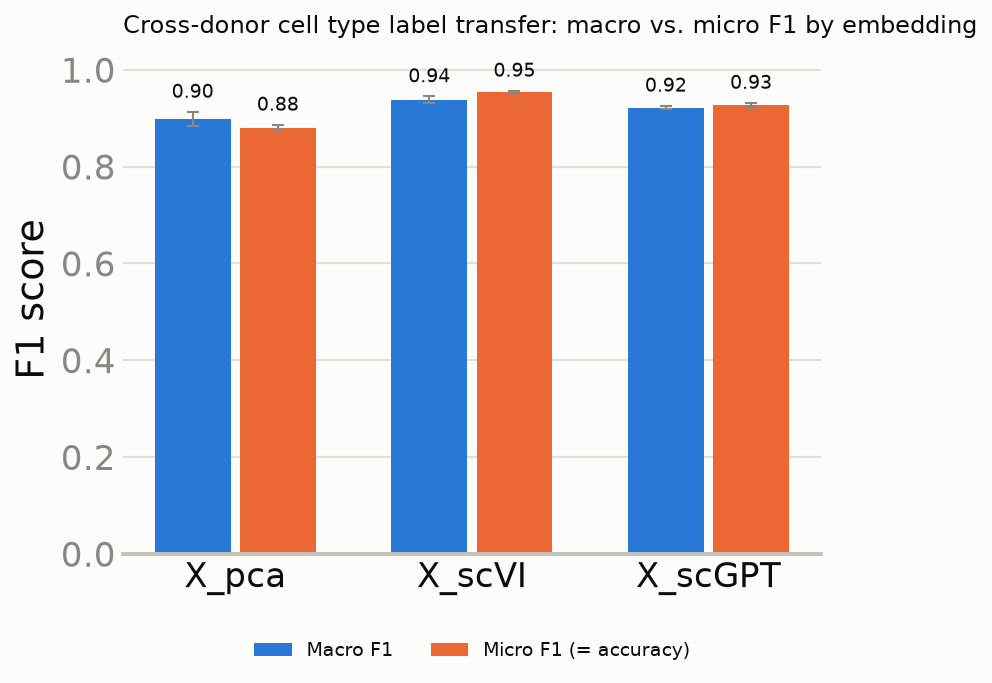

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- build summary_df from your results dict ---
summary_rows = []
for rep, fold_metrics in results.items():
    accs = [f["accuracy"] for f in fold_metrics]
    f1s = [f["macro_f1"] for f in fold_metrics]
    summary_rows.append({
        "embedding": rep,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s),
    })

summary_df = pd.DataFrame(summary_rows).set_index("embedding")
print(summary_df)

# --- grouped bar plot: macro F1 vs micro F1 (= accuracy), per embedding ---
COLOR_MACRO = "#2a78d6"   # blue
COLOR_MICRO = "#eb6834"   # orange
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_MUTED = "#898781"
SURFACE = "#fcfcfb"

embeddings = summary_df.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.32
gap = 0.04

fig, ax = plt.subplots(figsize=(6, 4.4), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars_macro = ax.bar(
    x - (bar_w + gap) / 2, summary_df["macro_f1_mean"], width=bar_w,
    yerr=summary_df["macro_f1_std"], capsize=3,
    color=COLOR_MACRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Macro F1",
)
bars_micro = ax.bar(
    x + (bar_w + gap) / 2, summary_df["accuracy_mean"], width=bar_w,
    yerr=summary_df["accuracy_std"], capsize=3,
    color=COLOR_MICRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Micro F1 (= accuracy)",
)

for bars, errs in (
    (bars_macro, summary_df["macro_f1_std"]),
    (bars_micro, summary_df["accuracy_std"]),
):
    for rect, err in zip(bars, errs):
        h = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2, h + err + 0.02,
            f"{h:.2f}", ha="center", va="bottom",
            fontsize=9, color=COLOR_TEXT_PRIMARY,
        )

ax.yaxis.grid(True, color=COLOR_GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)

ax.set_xticks(x)
ax.set_xticklabels(embeddings, color=COLOR_TEXT_PRIMARY)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis="y", colors=COLOR_TEXT_MUTED, length=0)
ax.tick_params(axis="x", length=0)

ax.set_ylabel("F1 score", color=COLOR_TEXT_PRIMARY)
ax.set_title(
    "Cross-donor cell type label transfer: macro vs. micro F1 by embedding",
    color=COLOR_TEXT_PRIMARY, loc="left", fontsize=11.5,
)

ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14),
    ncol=2, fontsize=9, labelcolor=COLOR_TEXT_PRIMARY,
)

fig.savefig(
    "embedding_f1_barplot.png", facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)
plt.show()

In [13]:
per_class_rows = []
for rep, fold_metrics in results.items():
    for fold_i, f in enumerate(fold_metrics):
        report = f["report"]
        for class_name, metrics in report.items():
            if class_name in ("accuracy", "macro avg", "weighted avg"):
                continue
            per_class_rows.append({
                "embedding": rep,
                "fold": fold_i,
                "cell_type": class_name,
                "f1": metrics["f1-score"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "support": metrics["support"],
            })

per_class_df = pd.DataFrame(per_class_rows)

# average F1 per embedding x cell type across folds
per_class_pivot = (
    per_class_df.groupby(["cell_type", "embedding"])["f1"]
    .mean()
    .unstack("embedding")
    .sort_values(by=per_class_df["embedding"].unique()[0], ascending=False)
)
print(per_class_pivot)

embedding                           X_pca   X_scGPT    X_scVI
cell_type                                                    
plasmacytoid dendritic cell      0.997468  0.991035  1.000000
B cell                           0.994399  0.998837  0.999205
classical monocyte               0.977277  0.981171  0.986015
plasmablast                      0.970053  0.970053  0.967374
non-classical monocyte           0.951218  0.923128  0.950823
conventional dendritic cell      0.900621  0.871462  0.880697
progenitor cell                  0.886522  0.938791  0.942393
natural killer cell              0.860838  0.953295  0.968707
CD4-positive, alpha-beta T cell  0.837562  0.909824  0.942718
lymphocyte                       0.782666  0.776123  0.775272
CD8-positive, alpha-beta T cell  0.722035  0.825016  0.903665


embedding                           X_pca   X_scGPT    X_scVI
cell_type                                                    
B cell                           0.994399  0.998837  0.999205
plasmacytoid dendritic cell      0.997468  0.991035  1.000000
classical monocyte               0.977277  0.981171  0.986015
plasmablast                      0.970053  0.970053  0.967374
non-classical monocyte           0.951218  0.923128  0.950823
natural killer cell              0.860838  0.953295  0.968707
progenitor cell                  0.886522  0.938791  0.942393
CD4-positive, alpha-beta T cell  0.837562  0.909824  0.942718
conventional dendritic cell      0.900621  0.871462  0.880697
CD8-positive, alpha-beta T cell  0.722035  0.825016  0.903665
lymphocyte                       0.782666  0.776123  0.775272


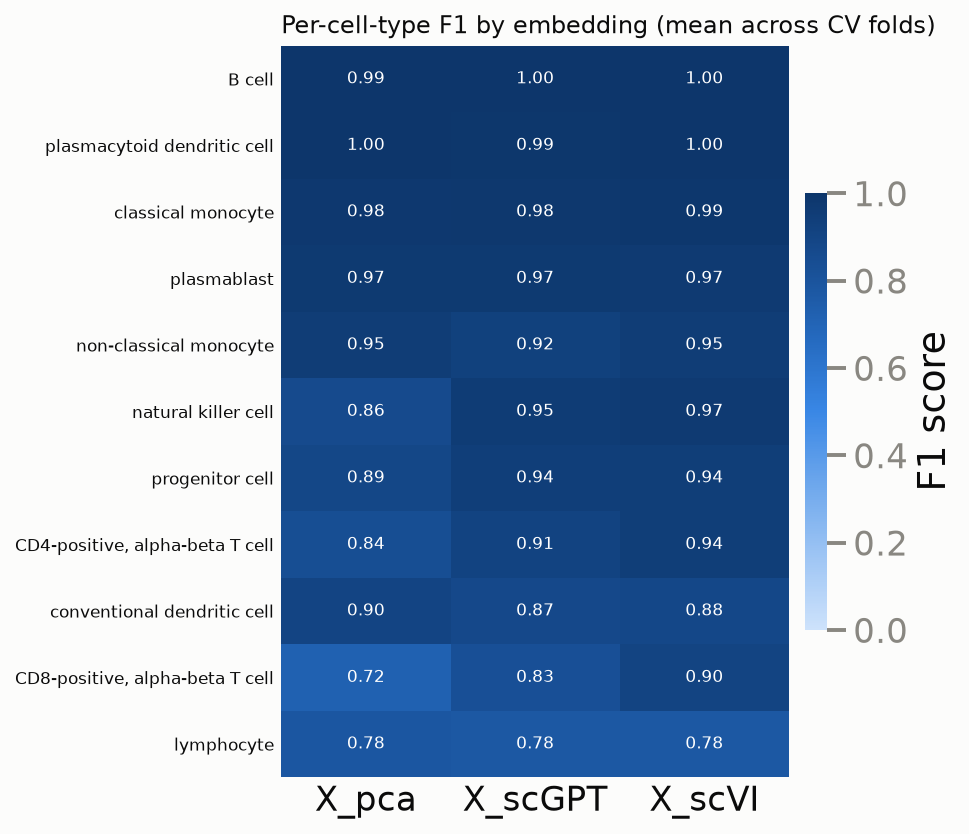

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- your existing per-class aggregation ---
per_class_rows = []
for rep, fold_metrics in results.items():
    for fold_i, f in enumerate(fold_metrics):
        report = f["report"]
        for class_name, metrics in report.items():
            if class_name in ("accuracy", "macro avg", "weighted avg"):
                continue
            per_class_rows.append({
                "embedding": rep,
                "fold": fold_i,
                "cell_type": class_name,
                "f1": metrics["f1-score"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "support": metrics["support"],
            })

per_class_df = pd.DataFrame(per_class_rows)

per_class_pivot = (
    per_class_df.groupby(["cell_type", "embedding"])["f1"]
    .mean()
    .unstack("embedding")
)
# sort by mean F1 across embeddings (descending) rather than one arbitrary column
per_class_pivot = per_class_pivot.loc[
    per_class_pivot.mean(axis=1).sort_values(ascending=False).index
]
print(per_class_pivot)

# --- heatmap ---
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_MUTED = "#898781"
SURFACE = "#fcfcfb"

# validated sequential blue ramp (light -> dark = low -> high F1)
blue_ramp = [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b",
]
cmap = LinearSegmentedColormap.from_list("f1_blue", blue_ramp)

data = per_class_pivot.values
n_rows, n_cols = data.shape

fig, ax = plt.subplots(figsize=(1.6 * n_cols + 2, 0.4 * n_rows + 1.5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(per_class_pivot.columns, color=COLOR_TEXT_PRIMARY)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(per_class_pivot.index, color=COLOR_TEXT_PRIMARY, fontsize=8)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# value labels, white on dark cells / ink on light cells for contrast
for i in range(n_rows):
    for j in range(n_cols):
        val = data[i, j]
        if np.isnan(val):
            continue
        text_color = "#ffffff" if val > 0.55 else COLOR_TEXT_PRIMARY
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("F1 score", color=COLOR_TEXT_PRIMARY)
cbar.ax.yaxis.set_tick_params(color=COLOR_TEXT_MUTED, labelcolor=COLOR_TEXT_MUTED)
cbar.outline.set_visible(False)

ax.set_title(
    "Per-cell-type F1 by embedding (mean across CV folds)",
    color=COLOR_TEXT_PRIMARY, loc="left", fontsize=11.5,
)

fig.tight_layout()
plt.show()

In [14]:
low_support = per_class_df[per_class_df["support"] < 10]
print(low_support[["embedding", "fold", "cell_type", "support"]].sort_values("support"))

# classes that don't appear in every fold for every embedding
n_folds = per_class_df["fold"].nunique()
counts = per_class_df.groupby(["embedding", "cell_type"])["fold"].nunique()
missing = counts[counts < n_folds]
print(missing)

    embedding  fold        cell_type  support
10      X_pca     0  progenitor cell      5.0
43      X_pca     3  progenitor cell      5.0
65     X_scVI     0  progenitor cell      5.0
98     X_scVI     3  progenitor cell      5.0
120   X_scGPT     0  progenitor cell      5.0
153   X_scGPT     3  progenitor cell      5.0
32      X_pca     2  progenitor cell      8.0
87     X_scVI     2  progenitor cell      8.0
142   X_scGPT     2  progenitor cell      8.0
19      X_pca     1      plasmablast      9.0
74     X_scVI     1      plasmablast      9.0
129   X_scGPT     1      plasmablast      9.0
Series([], Name: fold, dtype: int64)
